# 60 Multi-Model Comparison

Aggregates baseline and LoRA metrics across models and plots comparison charts.


In [4]:
# Cell 0: Load metrics and setup shared paths.
from pathlib import Path
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path('/home/rameyjm7/workspace/llamafactory-gemma-lora')
EXPRESS_ROOT = PROJECT_ROOT / 'express-emotion-recognition'
METRICS_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'all_models_metrics.csv'
FIGURE_OUT = PROJECT_ROOT / 'outputs' / 'figures' / 'figure2_baseline_plus_lora_overlay.png'

if METRICS_PATH.exists():
    lora_df = pd.read_csv(METRICS_PATH)
    print('Loaded LoRA metrics rows:', len(lora_df))
    display(lora_df[['model_id', 'family', 'size_b', 'accv', 'clean_output_path']].tail(20))
else:
    lora_df = pd.DataFrame()
    print('Missing', METRICS_PATH)


Loaded LoRA metrics rows: 13


,model_id,family,size_b,accv,clean_output_path
0,mental_roberta_base,roberta,0.125,0.454527,/home/rameyjm7/workspace/llamafactory-gemma-lo...
1,flan_t5_large,flan-t5,0.780,0.267298,/home/rameyjm7/workspace/llamafactory-gemma-lo...
2,longformer_base,longformer,0.149,0.460696,/home/rameyjm7/workspace/llamafactory-gemma-lo...
3,flan_t5_xl,flan-t5,3.000,0.412825,/home/rameyjm7/workspace/llamafactory-gemma-lo...
4,llama31_8b_instruct,llama3.1,8.000,0.417893,/home/rameyjm7/workspace/llamafactory-gemma-lo...
5,roberta_base,roberta,0.125,0.464322,/home/rameyjm7/workspace/llamafactory-gemma-lo...
6,deberta_v3_large,deberta,0.435,0.045996,/home/rameyjm7/workspace/llamafactory-gemma-lo...
7,gemma2_2b_it,gemma2,2.000,0.217442,/home/rameyjm7/workspace/llamafactory-gemma-lo...
8,roberta_base_baseline_like,roberta,0.125,0.468813,/home/rameyjm7/workspace/llamafactory-gemma-lo...
9,roberta_base_lower_lr_more_epochs,roberta,0.125,0.463095,/home/rameyjm7/workspace/llamafactory-gemma-lo...


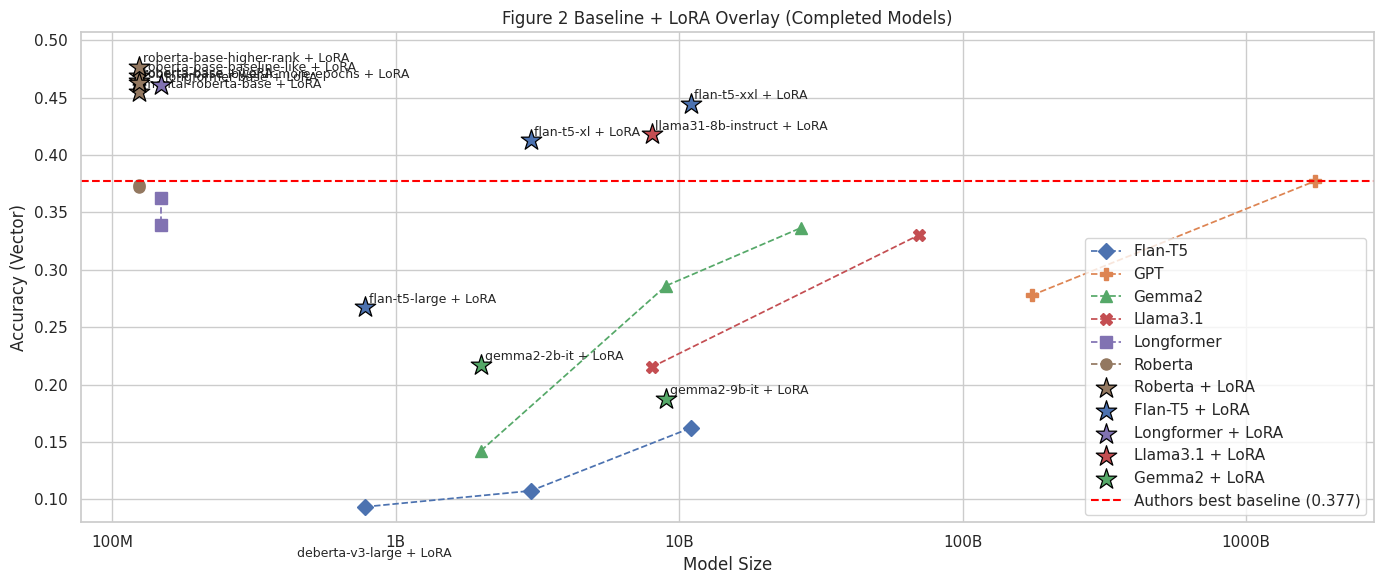

Saved figure: /home/rameyjm7/workspace/llamafactory-gemma-lora/outputs/figures/figure2_baseline_plus_lora_overlay.png


,model_id,base_label,base_accv,accv,delta_accv
3,flan_t5_xl,Flan-T5-xl,0.107395,0.412825,0.305429
11,flan_t5_xxl,Flan-T5-xxl,0.162174,0.444554,0.282380
4,llama31_8b_instruct,Llama3.1-8B-instruct,0.215170,0.417893,0.202724
1,flan_t5_large,Flan-T5-large,0.093452,0.267298,0.173846
2,longformer_base,Longformer-base,0.362879,0.460696,0.097817
5,roberta_base,Roberta-base,0.373539,0.464322,0.090783
0,mental_roberta_base,Mental-Roberta-base,0.371861,0.454527,0.082666
7,gemma2_2b_it,Gemma-2-2B-it,0.142316,0.217442,0.075126
12,gemma2_9b_it,Gemma-2-9B-it,0.286057,0.187716,-0.098341
6,deberta_v3_large,NaN,NaN,0.045996,NaN


In [5]:
# Cell 1: Reproduce Figure-2-style baseline and overlay available LoRA results.
lex_df = pd.read_csv(EXPRESS_ROOT / 'data' / 'lexicon-decomposition.csv')
vec_map = {str(r['word']).lower(): tuple(int(v) for v in r.iloc[1:].tolist()) for _, r in lex_df.iterrows()}
zero_vec = tuple([0] * 10)

_parse_cache = {}
def parse_list_cached(raw):
    if isinstance(raw, list):
        return [str(x).strip().lower() for x in raw]
    if not isinstance(raw, str):
        return None
    s = raw.strip()
    if s == 'INVALID OUTPUT':
        return None
    if s in _parse_cache:
        return _parse_cache[s]
    try:
        v = ast.literal_eval(s)
        parsed = [str(x).strip().lower() for x in v] if isinstance(v, list) else None
    except Exception:
        parsed = None
    _parse_cache[s] = parsed
    return parsed


def compute_accv(csv_path):
    df = pd.read_csv(csv_path, usecols=['labels', 'output_formatted', 'number_of_labels'])
    total_masks = int(df['number_of_labels'].sum())
    matches = 0
    for raw_labels, raw_preds in zip(df['labels'].tolist(), df['output_formatted'].tolist()):
        labels = parse_list_cached(raw_labels)
        preds = parse_list_cached(raw_preds)
        if labels is None or preds is None:
            continue
        for t, p in zip(labels, preds):
            matches += int(vec_map.get(t, zero_vec) == vec_map.get(p, zero_vec))
    return (matches / total_masks) if total_masks > 0 else float('nan')

baseline_models = [
    {'model_id': 'flan_t5_large', 'label': 'Flan-T5-large', 'family': 'Flan-T5', 'size_b': 0.78, 'file': 'flan_t5_large.csv'},
    {'model_id': 'flan_t5_xl', 'label': 'Flan-T5-xl', 'family': 'Flan-T5', 'size_b': 3.0, 'file': 'flan_t5_xl.csv'},
    {'model_id': 'flan_t5_xxl', 'label': 'Flan-T5-xxl', 'family': 'Flan-T5', 'size_b': 11.0, 'file': 'flan_t5_xxl.csv'},
    {'model_id': 'gpt_35_turbo', 'label': 'Gpt-3.5-turbo', 'family': 'GPT', 'size_b': 175.0, 'file': 'gpt_35_turbo_0125.csv'},
    {'model_id': 'gpt_4o', 'label': 'Gpt-4o', 'family': 'GPT', 'size_b': 1750.0, 'file': 'gpt_4o.csv'},
    {'model_id': 'gemma2_2b_it', 'label': 'Gemma-2-2B-it', 'family': 'Gemma2', 'size_b': 2.0, 'file': 'gemma2_2B_it.csv'},
    {'model_id': 'gemma2_9b_it', 'label': 'Gemma-2-9B-it', 'family': 'Gemma2', 'size_b': 9.0, 'file': 'gemma2_9B_it.csv'},
    {'model_id': 'gemma2_27b_it', 'label': 'Gemma-2-27B-it', 'family': 'Gemma2', 'size_b': 27.0, 'file': 'gemma2_27B_it.csv'},
    {'model_id': 'llama31_8b_instruct', 'label': 'Llama3.1-8B-instruct', 'family': 'Llama3.1', 'size_b': 8.0, 'file': 'llama3.1_8B_instruct.csv'},
    {'model_id': 'llama31_70b_instruct', 'label': 'Llama3.1-70B-instruct', 'family': 'Llama3.1', 'size_b': 70.0, 'file': 'llama3.1_70B_instruct.csv'},
    {'model_id': 'longformer_base', 'label': 'Longformer-base', 'family': 'Longformer', 'size_b': 0.149, 'file': 'longformer.csv'},
    {'model_id': 'mental_longformer_base', 'label': 'Mental-Longformer-base', 'family': 'Longformer', 'size_b': 0.149, 'file': 'mental-longformer.csv'},
    {'model_id': 'roberta_base', 'label': 'Roberta-base', 'family': 'Roberta', 'size_b': 0.125, 'file': 'roberta-base.csv'},
    {'model_id': 'mental_roberta_base', 'label': 'Mental-Roberta-base', 'family': 'Roberta', 'size_b': 0.125, 'file': 'mental-roberta-base.csv'},
]

base_rows = []
for m in baseline_models:
    csv_path = EXPRESS_ROOT / 'results' / m['file']
    base_rows.append({**m, 'accv': compute_accv(csv_path)})
base_df = pd.DataFrame(base_rows)


def normalize_model_id(x):
    return str(x).strip().lower().replace('-', '_').replace('.', '_')

if not lora_df.empty:
    lo = lora_df.copy()
    lo['model_id_norm'] = lo['model_id'].map(normalize_model_id)
    lo['accv'] = pd.to_numeric(lo['accv'], errors='coerce')
    lo['size_b'] = pd.to_numeric(lo['size_b'], errors='coerce')
    lo = lo.dropna(subset=['accv', 'size_b'])

    if 'timestamp_utc' in lo.columns:
        lo = lo.sort_values('timestamp_utc').groupby('model_id_norm', as_index=False).tail(1)

    base_map = {normalize_model_id(x): x for x in base_df['model_id'].tolist()}
    lo['base_model_id'] = lo['model_id_norm'].map(lambda x: base_map.get(x, x))

    lora_plot = lo[['model_id', 'base_model_id', 'size_b', 'accv']].copy()
else:
    lora_plot = pd.DataFrame(columns=['model_id', 'base_model_id', 'size_b', 'accv'])

lora_plot = lora_plot.merge(
    base_df[['model_id', 'label', 'family', 'accv']].rename(columns={'model_id': 'base_model_id', 'label': 'base_label', 'accv': 'base_accv'}),
    on='base_model_id',
    how='left'
)
lora_plot['delta_accv'] = lora_plot['accv'] - lora_plot['base_accv']

sns.set_theme(style='whitegrid')
family_colors = {
    'Flan-T5': '#4C72B0',
    'GPT': '#DD8452',
    'Gemma2': '#55A868',
    'Llama3.1': '#C44E52',
    'Longformer': '#8172B2',
    'Roberta': '#937860',
}
family_markers = {
    'Flan-T5': 'D',
    'GPT': 'P',
    'Gemma2': '^',
    'Llama3.1': 'X',
    'Longformer': 's',
    'Roberta': 'o',
}

fig, ax = plt.subplots(figsize=(14, 6))
for fam in ['Flan-T5', 'GPT', 'Gemma2', 'Llama3.1', 'Longformer', 'Roberta']:
    sub = base_df[base_df['family'] == fam].sort_values('size_b')
    if sub.empty:
        continue
    ax.plot(
        sub['size_b'], sub['accv'],
        marker=family_markers[fam],
        color=family_colors[fam],
        linestyle='--',
        linewidth=1.25,
        markersize=8,
        label=fam,
    )

if not lora_plot.empty:
    shown = set()
    for r in lora_plot.itertuples(index=False):
        fam = r.family if isinstance(r.family, str) else 'Roberta'
        color = family_colors.get(fam, 'black')
        legend_label = f'{fam} + LoRA' if fam not in shown else None
        shown.add(fam)
        ax.scatter(
            [float(r.size_b)], [float(r.accv)],
            marker='*', s=240, color=color, edgecolors='black', linewidths=0.9,
            label=legend_label,
            zorder=5,
        )
        ann = str(r.model_id).replace('_', '-') + ' + LoRA'
        ax.text(float(r.size_b) * 1.03, float(r.accv) + 0.004, ann, fontsize=9)



authors_best_accv = float(base_df['accv'].max())
ax.axhline(
    y=authors_best_accv,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Authors best baseline ({authors_best_accv:.3f})",
)

ax.set_xscale('log')
ax.set_xlabel('Model Size')
ax.set_ylabel('Accuracy (Vector)')
y_max = 0.40
if not lora_plot.empty:
    y_max = max(y_max, float(lora_plot['accv'].max()) + 0.03)
ax.set_ylim(0.08, y_max)
ax.set_xticks([0.1, 1, 10, 100, 1000])
ax.set_xticklabels(['100M', '1B', '10B', '100B', '1000B'])
ax.set_title('Figure 2 Baseline + LoRA Overlay (Completed Models)')
ax.legend(loc='lower right')
fig.tight_layout()

FIGURE_OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_OUT, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure:', FIGURE_OUT)
if not lora_plot.empty:
    display(lora_plot[['model_id', 'base_label', 'base_accv', 'accv', 'delta_accv']].sort_values('delta_accv', ascending=False))


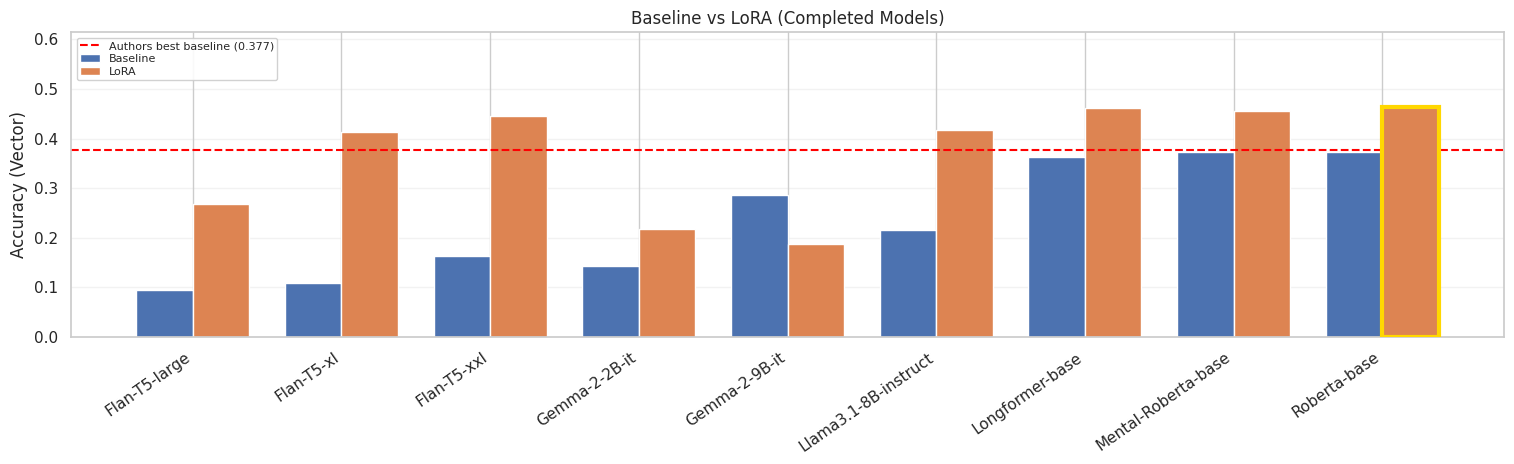

,base_model_id,base_label,baseline_accv,lora_accv
0,flan_t5_large,Flan-T5-large,0.093452,0.267298
1,flan_t5_xl,Flan-T5-xl,0.107395,0.412825
2,flan_t5_xxl,Flan-T5-xxl,0.162174,0.444554
3,gemma2_2b_it,Gemma-2-2B-it,0.142316,0.217442
4,gemma2_9b_it,Gemma-2-9B-it,0.286057,0.187716
5,llama31_8b_instruct,Llama3.1-8B-instruct,0.215170,0.417893
6,longformer_base,Longformer-base,0.362879,0.460696
7,mental_roberta_base,Mental-Roberta-base,0.371861,0.454527
8,roberta_base,Roberta-base,0.373539,0.464322


In [6]:
# Cell 2: Basic grouped bar chart (baseline vs LoRA where available).
import numpy as np

if 'base_df' not in globals() or 'lora_plot' not in globals():
    raise RuntimeError('Run Cell 1 first to build base_df and lora_plot.')

bar_df = lora_plot[['base_model_id', 'base_label', 'base_accv', 'accv']].copy()
bar_df = bar_df.dropna(subset=['base_accv', 'accv'])
bar_df = bar_df.rename(columns={'base_accv': 'baseline_accv', 'accv': 'lora_accv'})
bar_df = bar_df.sort_values('base_label').reset_index(drop=True)

if bar_df.empty:
    print('No completed LoRA rows yet in all_models_metrics.csv')
else:
    x = np.arange(len(bar_df))
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(8, len(bar_df) * 1.7), 4.8))
    baseline_bars = ax.bar(x - width / 2, bar_df['baseline_accv'], width=width, label='Baseline')
    lora_bars = ax.bar(x + width / 2, bar_df['lora_accv'], width=width, label='LoRA')

    # Highlight the highest bar across baseline+LoRA (outline, keep original color).
    all_bars = list(baseline_bars) + list(lora_bars)
    if all_bars:
        best_bar = max(all_bars, key=lambda b: b.get_height())
        best_bar.set_edgecolor('gold')
        best_bar.set_linewidth(3.0)
        best_bar.set_zorder(5)


    authors_best_accv = float(base_df['accv'].max())
    ax.axhline(
        y=authors_best_accv,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f"Authors best baseline ({authors_best_accv:.3f})",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(bar_df['base_label'], rotation=35, ha='right')
    ax.set_ylabel('Accuracy (Vector)')
    ax.set_title('Baseline vs LoRA (Completed Models)')
    y_top = max(float(bar_df['baseline_accv'].max()), float(bar_df['lora_accv'].max()), float(authors_best_accv))
    ax.set_ylim(0.0, y_top + 0.15)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9, borderpad=0.3, labelspacing=0.25, handlelength=1.8)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()

    display(bar_df)
